# Part II - Prosper Loans: Risk, Pricing, and Outcomes
## by José Luis Lázaro Contreras

## Investigation Overview

>This presentation summarizes the most important insights from the exploratory analysis of Prosper loans.  
>The main goal is to communicate how **borrower risk** is reflected in **loan pricing (APR)** and how pricing relates to **loan outcomes**.

### Executive Summary (Key Insights)
- Loan outcomes vary widely across categories, with a meaningful share of negative outcomes (e.g., Chargedoff/Defaulted). 
- Lower borrower credit scores are associated with higher APR values, suggesting risk-based pricing. 
- Loans with negative outcomes tend to have higher APR distributions compared to completed loans. 

## Dataset Overview and Executive Summary

>The Prosper Loan dataset contains loan-level records with borrower credit information, loan characteristics, and performance outcomes.  
In this presentation we focus on: `LoanStatus`, `BorrowerAPR`, and credit score ranges as a proxy for risk. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")

sns.set_style("whitegrid")

# Load (use the same loading strategy you used in Part I)
import csv
df_loans = pd.read_csv(
    "prosperLoanData.csv",
    sep=";",
    engine="python",
    quoting=csv.QUOTE_NONE,
    escapechar="\\",
    on_bad_lines="skip",
    encoding_errors="replace"
)

# Numeric conversions used in plots
for c in ["BorrowerAPR", "BorrowerRate", "CreditScoreRangeLower", "DebtToIncomeRatio", "LoanOriginalAmount"]:
    if c in df_loans.columns:
        df_loans[c] = pd.to_numeric(df_loans[c], errors="coerce")

## Visualization 1: LoanStatus distribution


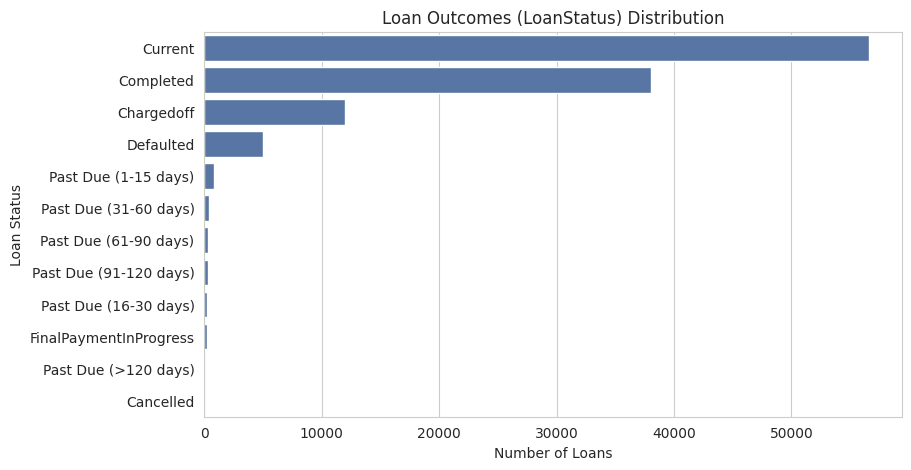

In [2]:
# load in the dataset into a pandas dataframe
plt.figure(figsize=(9, 5))

order = df_loans["LoanStatus"].value_counts().index
sns.countplot(data=df_loans, y="LoanStatus", order=order, color="#4C72B0")

plt.title("Loan Outcomes (LoanStatus) Distribution")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Status")
plt.show()

## Comment
> **What this shows:** Loan outcomes are not evenly distributed. A large share of loans are Current or Completed, but a meaningful portion fall into negative outcomes such as Chargedoff/Defaulted, which motivates analyzing borrower risk and pricing. 

## Visualization 2: Risk (Credit Score) vs APR (Scatter)

> Here, we add a simple trendline with regplot (very presentable) and limit APR for visual clarity (for visualization purposes only).



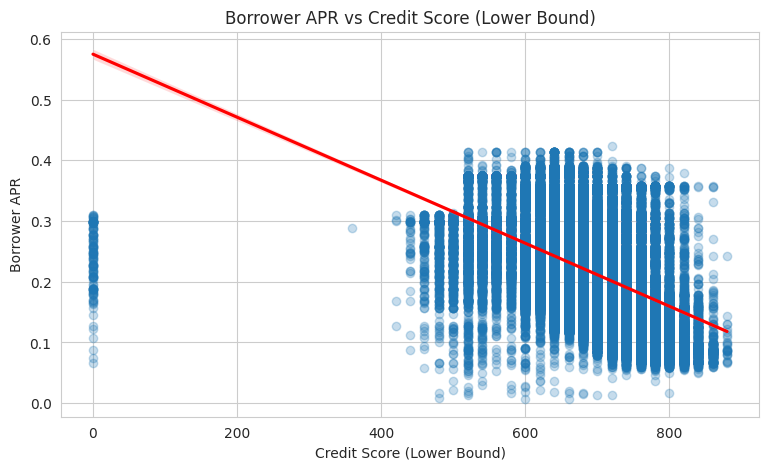

In [3]:
plot_df = df_loans[["CreditScoreRangeLower", "BorrowerAPR"]].dropna()
plot_df = plot_df[(plot_df["BorrowerAPR"] >= 0) & (plot_df["BorrowerAPR"] <= 0.6)]

plt.figure(figsize=(9, 5))

sns.regplot(
    data=plot_df,
    x="CreditScoreRangeLower",
    y="BorrowerAPR",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)

plt.title("Borrower APR vs Credit Score (Lower Bound)")
plt.xlabel("Credit Score (Lower Bound)")
plt.ylabel("Borrower APR")
plt.show()


## Comment

> **What this shows:** Borrower APR decreases as credit score increases, indicating risk-based pricing: lower credit scores are associated with higher borrowing costs

## Visualization 3: APR by LoanStatus (Boxplot + Global Median)



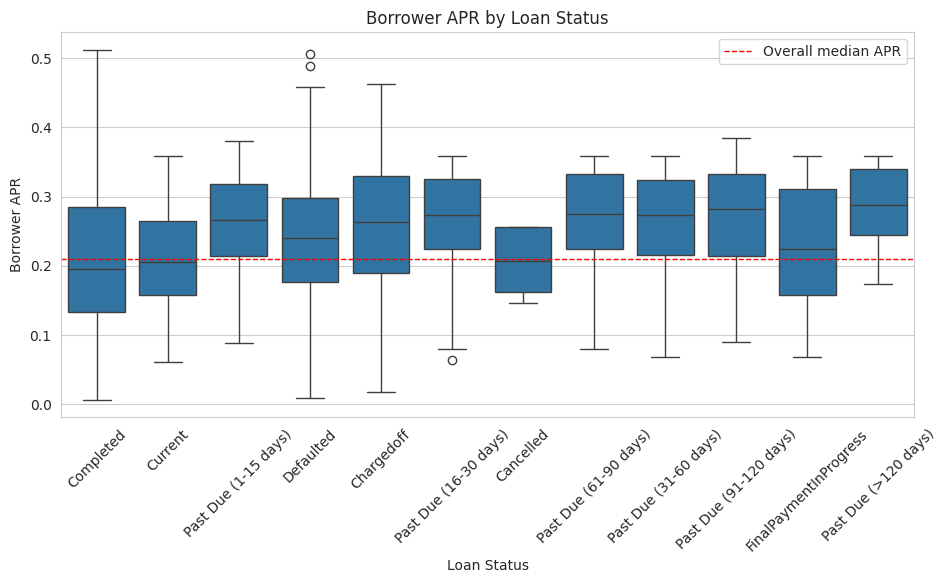

In [4]:
box_df = df_loans[["LoanStatus", "BorrowerAPR"]].dropna()
box_df = box_df[(box_df["BorrowerAPR"] >= 0) & (box_df["BorrowerAPR"] <= 0.6)]

median_apr = box_df["BorrowerAPR"].median()

plt.figure(figsize=(11, 5))
sns.boxplot(data=box_df, x="LoanStatus", y="BorrowerAPR")

plt.axhline(median_apr, color="red", linestyle="--", linewidth=1, label="Overall median APR")
plt.title("Borrower APR by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Borrower APR")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Comment

> **What this shows:** Loan statuses associated with negative outcomes tend to show higher APR distributions compared to completed loans. The overall median APR line helps contextualize which groups are priced above typical levels.

## Visualization 4: Bars by Rating or by Term



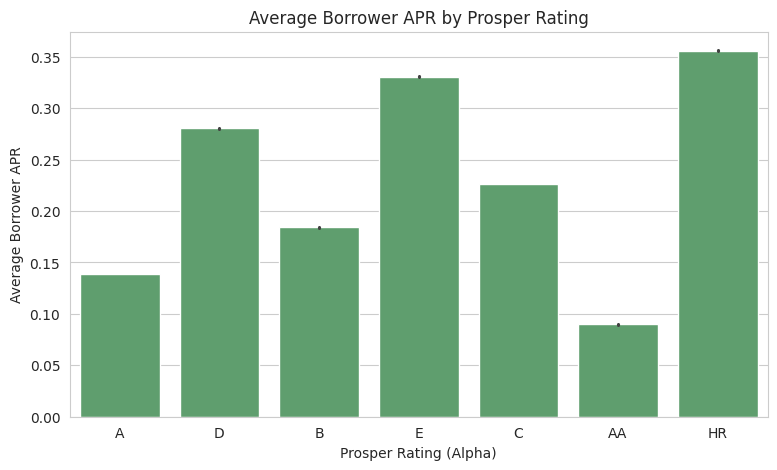

In [5]:
if "ProsperRating (Alpha)" in df_loans.columns:
    tmp = df_loans[["ProsperRating (Alpha)", "BorrowerAPR"]].dropna()
    tmp = tmp[(tmp["BorrowerAPR"] >= 0) & (tmp["BorrowerAPR"] <= 0.6)]

    plt.figure(figsize=(9, 5))
    sns.barplot(data=tmp, x="ProsperRating (Alpha)", y="BorrowerAPR", color="#55A868")
    plt.title("Average Borrower APR by Prosper Rating")
    plt.xlabel("Prosper Rating (Alpha)")
    plt.ylabel("Average Borrower APR")
    plt.show()

## Comment

>This visualization shows how the **average Borrower APR varies across Prosper Rating categories**. A clear and consistent pattern emerges: **lower credit ratings are associated with higher average APR values**, while higher ratings correspond to lower borrowing costs.

>This pattern reinforces the concept of **risk-based pricing**. Borrowers assessed as higher risk are charged higher interest rates to compensate lenders for the increased probability of default, whereas borrowers with stronger credit profiles benefit from more favorable rates.

>Overall, this chart complements earlier insights by showing that borrower risk classifications not only relate to loan outcomes, but also play a central role in determining the cost of credit at the time of loan origination.
